In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

Business Objective
Predict the Order Status using customer and sales information.

Dataset Shape
(4310, 21)

Columns
Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='object')

First Five Rows
    order_id  order_date customer_id customer_name   age gender   region  \
0  ORD-03903  2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198  2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348  2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076  2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
4  ORD-00287  2020-05-07   CUST58035   Ritu Sharma   9.0   Male  Central   

        city product_category product_name  ...

/tmp/ipykernel_919/2127075110.py:45: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["order_date"] = pd.to_datetime(



Accuracy : 0.6661608497723824

Classification Report
              precision    recall  f1-score   support

           0       0.67      0.05      0.09        43
           1       0.66      0.99      0.80       432
           2       0.00      0.00      0.00        17
           3       0.71      0.05      0.10        92
           4       0.00      0.00      0.00        51
           5       0.00      0.00      0.00         2
           6       1.00      0.11      0.19        19
           7       0.00      0.00      0.00         1
           8       1.00      0.50      0.67         2

    accuracy                           0.67       659
   macro avg       0.45      0.19      0.20       659
weighted avg       0.61      0.67      0.55       659



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


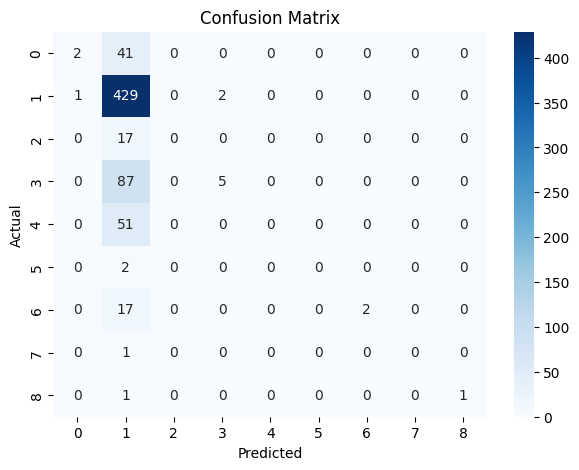

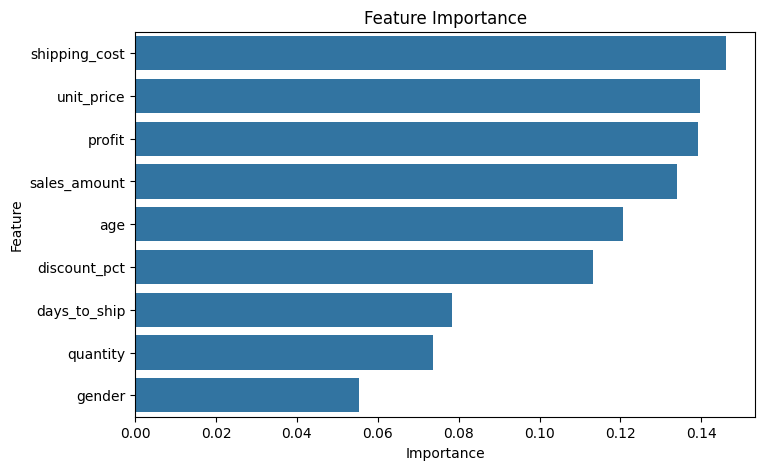


CRISP-DM Completed Successfully!


In [3]:

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------
# BUSINESS UNDERSTANDING
# ---------------------------------------------------

print("Business Objective")
print("Predict the Order Status using customer and sales information.\n")

# ---------------------------------------------------
# DATA UNDERSTANDING
# ---------------------------------------------------

print("Dataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nFirst Five Rows")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

# ---------------------------------------------------
# DATA PREPARATION
# ---------------------------------------------------

# Convert Date

df["order_date"] = pd.to_datetime(
    df["order_date"],
    dayfirst=True,
    errors="coerce"
)

# Remove missing rows

df.dropna(inplace=True)

# Encode Categorical Columns

encoder = LabelEncoder()

categorical_columns = [
    "customer_name",
    "gender",
    "region",
    "city",
    "product_category",
    "product_name",
    "payment_method",
    "customer_satisfaction",
    "return_flag",
    "order_status"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

# ---------------------------------------------------
# Feature Selection
# ---------------------------------------------------

X = df[
    [
        "age",
        "gender",
        "quantity",
        "unit_price",
        "discount_pct",
        "sales_amount",
        "profit",
        "shipping_cost",
        "days_to_ship"
    ]
]

y = df["order_status"]

# ---------------------------------------------------
# Split Dataset
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# ---------------------------------------------------
# MODEL BUILDING
# ---------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------
# PREDICTION
# ---------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------
# EVALUATION
# ---------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", accuracy)

print("\nClassification Report")

print(classification_report(y_test, y_pred))

# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------
# Feature Importance
# ---------------------------------------------------

importance = pd.DataFrame(
    {
        "Feature":X.columns,
        "Importance":model.feature_importances_
    }
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

print("\nCRISP-DM Completed Successfully!")

========== SAMPLE ==========
Original Dataset Shape : (3291, 21)
Sample Dataset Shape   : (2633, 21)

========== EXPLORE ==========
                          order_date  customer_name          age       gender  \
count                           2633     2633.00000  2633.000000  2633.000000   
mean   2022-07-04 07:49:47.466767872      199.35093    34.979491     4.514242   
min              2020-01-01 00:00:00        0.00000    -7.000000     0.000000   
25%              2021-04-20 00:00:00       98.00000    26.000000     2.000000   
50%              2022-07-09 00:00:00      198.00000    34.000000     5.000000   
75%              2023-09-27 00:00:00      301.00000    42.000000     6.000000   
max              2024-12-30 00:00:00      399.00000   999.000000    10.000000   
std                              NaN      115.25612    29.354704     1.981460   

            region         city  product_category  product_name     quantity  \
count  2633.000000  2633.000000       2633.000000   2633.0

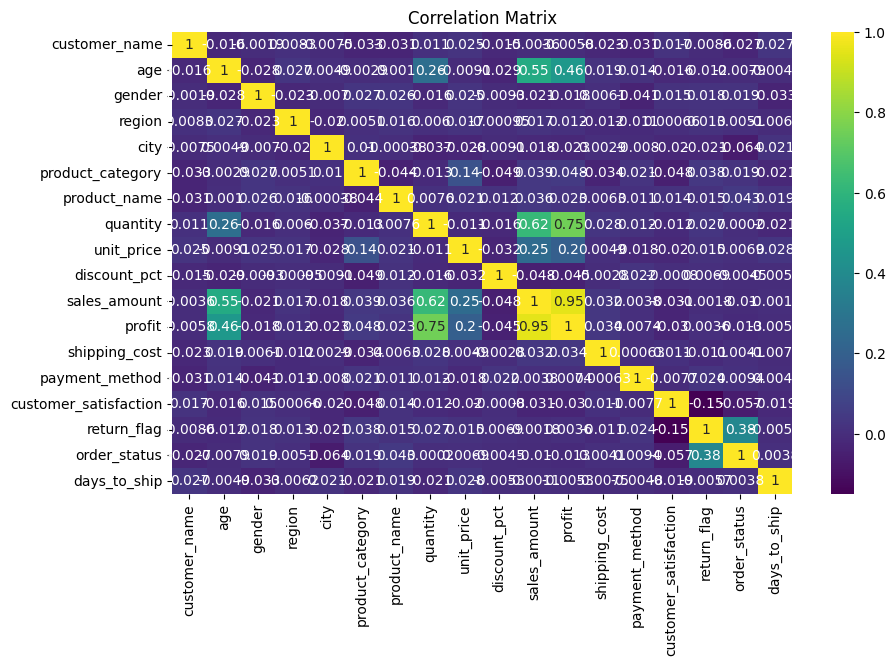


========== MODIFY ==========
Training Data : (2106, 9)
Testing Data  : (527, 9)

========== MODEL ==========

========== ASSESS ==========
Accuracy : 0.6261859582542695

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.06      0.11        35
           1       0.63      0.99      0.77       325
           2       0.00      0.00      0.00        21
           3       0.57      0.05      0.09        85
           4       0.50      0.02      0.04        43
           5       0.00      0.00      0.00         3
           6       1.00      0.08      0.15        12
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         2

    accuracy                           0.63       527
   macro avg       0.41      0.13      0.13       527
weighted avg       0.61      0.63      0.50       527



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


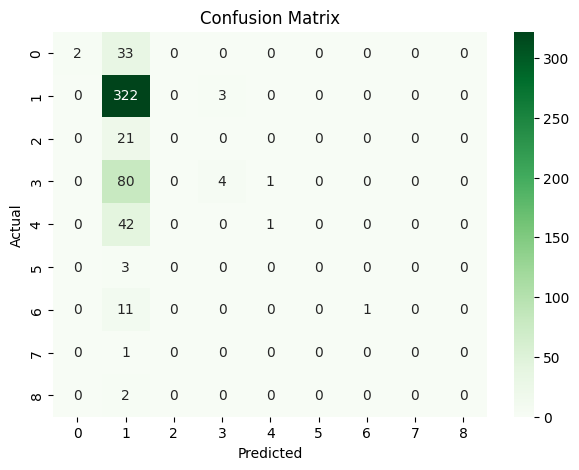

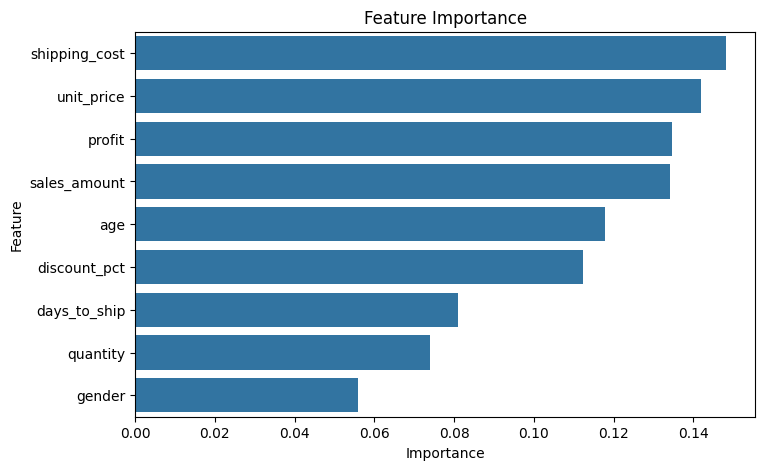

In [4]:


from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ---------------------------------------------------
# SAMPLE
# ---------------------------------------------------

print("========== SAMPLE ==========")

sample_df = df.sample(frac=0.80, random_state=42)

print("Original Dataset Shape :", df.shape)
print("Sample Dataset Shape   :", sample_df.shape)

# ---------------------------------------------------
# EXPLORE
# ---------------------------------------------------

print("\n========== EXPLORE ==========")

print(sample_df.describe())

plt.figure(figsize=(10,6))

sns.heatmap(
    sample_df.corr(numeric_only=True),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Matrix")

plt.show()

# ---------------------------------------------------
# MODIFY
# ---------------------------------------------------

print("\n========== MODIFY ==========")

X = sample_df[
    [
        "age",
        "gender",
        "quantity",
        "unit_price",
        "discount_pct",
        "sales_amount",
        "profit",
        "shipping_cost",
        "days_to_ship"
    ]
]

y = sample_df["order_status"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

# ---------------------------------------------------
# MODEL
# ---------------------------------------------------

print("\n========== MODEL ==========")

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ---------------------------------------------------
# ASSESS
# ---------------------------------------------------

print("\n========== ASSESS ==========")

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ---------------------------------------------------
# Feature Importance
# ---------------------------------------------------

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()


========== KDD METHODOLOGY ==========

STEP 1 : DATA SELECTION
    age  gender  quantity  unit_price  discount_pct  sales_amount    profit  \
1  28.0       5       8.0      858.66          0.08       9147.31   5355.56   
2  41.0       6       4.0    25941.32          0.14     110156.97  36956.51   
3  29.0       6       9.0    22071.92          0.17     262066.11  66644.99   
4   9.0       5       1.0      320.06          0.31        323.95     31.38   
6  31.0       2       3.0      329.03          0.02        994.87    375.07   

   shipping_cost  days_to_ship  order_status  
1          64.49           2.0             1  
2          67.65           5.0             1  
3          54.47           4.0             1  
4          48.81           4.0             2  
6          77.34          10.0             3  

STEP 2 : PREPROCESSING

Missing Values Before Cleaning
age              0
gender           0
quantity         0
unit_price       0
discount_pct     0
sales_amount     0
profit    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


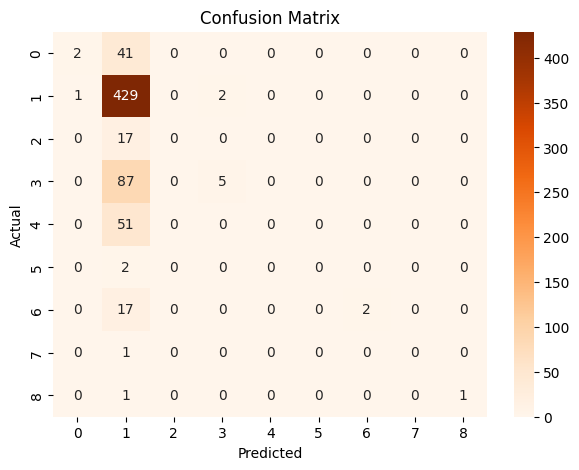

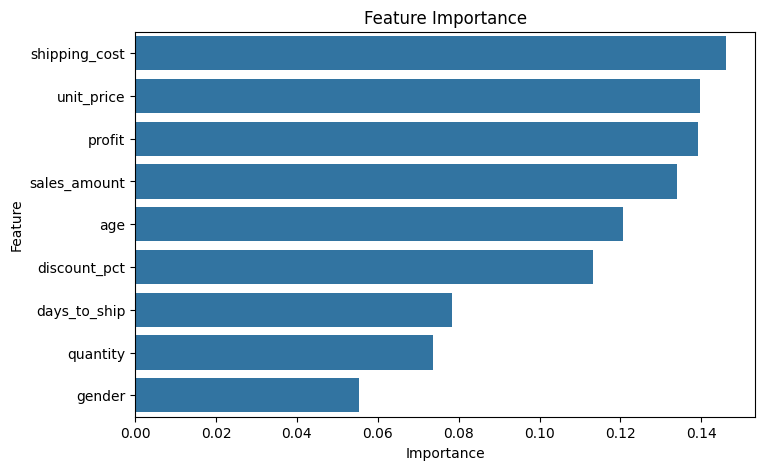


Sample Predictions
   Actual  Predicted
0       3          1
1       1          1
2       3          1
3       3          1
4       3          1
5       3          1
6       1          1
7       1          1
8       1          1
9       1          1


In [5]:


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("========== KDD METHODOLOGY ==========\n")

# ---------------------------------------------------
# STEP 1 : SELECTION
# ---------------------------------------------------

print("STEP 1 : DATA SELECTION")

selected_df = df[[
    "age",
    "gender",
    "quantity",
    "unit_price",
    "discount_pct",
    "sales_amount",
    "profit",
    "shipping_cost",
    "days_to_ship",
    "order_status"
]].copy()

print(selected_df.head())

# ---------------------------------------------------
# STEP 2 : PREPROCESSING
# ---------------------------------------------------

print("\nSTEP 2 : PREPROCESSING")

print("\nMissing Values Before Cleaning")

print(selected_df.isnull().sum())

selected_df.dropna(inplace=True)

print("\nMissing Values After Cleaning")

print(selected_df.isnull().sum())

# ---------------------------------------------------
# STEP 3 : TRANSFORMATION
# ---------------------------------------------------

print("\nSTEP 3 : TRANSFORMATION")

encoder = LabelEncoder()

selected_df["gender"] = encoder.fit_transform(selected_df["gender"])

selected_df["order_status"] = encoder.fit_transform(selected_df["order_status"])

print(selected_df.head())

# ---------------------------------------------------
# STEP 4 : DATA MINING
# ---------------------------------------------------

print("\nSTEP 4 : DATA MINING")

X = selected_df.drop("order_status", axis=1)

y = selected_df["order_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(X_train, y_train)

prediction = classifier.predict(X_test)

# ---------------------------------------------------
# STEP 5 : INTERPRETATION / EVALUATION
# ---------------------------------------------------

print("\nSTEP 5 : EVALUATION")

accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

print("\nClassification Report\n")

print(classification_report(y_test, prediction))

# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ---------------------------------------------------
# Feature Importance
# ---------------------------------------------------

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":classifier.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

# ---------------------------------------------------
# Prediction Sample
# ---------------------------------------------------

comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":prediction
})

print("\nSample Predictions")

print(comparison.head(10))
